In [13]:
# necessary imports and folders
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter

ROOT = Path(
    "/Users/HP/Documents/second-publication/current-analysis/re-run/rq1-rerun"
)
FEAS_DATA = ROOT / "raw-responses/feasibility_humanOnly_rq1.csv"
IMP_DATA = ROOT / "raw-responses/importance_humanOnly_rq1.csv"
BARRIER_DATA = ROOT / "raw-responses/barriers_human_final.csv"


OUTPUT = ROOT / "experts-consistency/output/"
create_output_dir = OUTPUT.mkdir(parents=True, exist_ok=True)

In [ ]:
# Feasibility — Leave-one-expert-out stability # loo = leave-one-out
# The substantive conclusion that this assessment brings is defined here as: median rating ≥ 3; and at least 50% of experts rate feasibility ≥ 3.
df = pd.read_csv(FEAS_DATA)
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df = df.dropna(subset=["row_id", "rating"]).reset_index(drop=True)

full_median = df["rating"].median()
full_proportion = (df["rating"] >= 3).mean()

full_conclusion = (
    (full_median >= 3) and
    (full_proportion >= 0.50)
)

loo_results = []

for removed_index, removed_row in df.iterrows():
    remaining = df.drop(index=removed_index)
    
    loo_median = remaining["rating"].median()
    loo_proportion = (remaining["rating"] >= 3).mean()
    
    loo_conclusion = (
        (loo_median >= 3) and
        (loo_proportion >= 0.50)
    )
    
    loo_results.append({
        "removed_expert": removed_row["row_id"],
        "removed_rating": removed_row["rating"],
        "loo_n_experts": len(remaining),
        "loo_median": loo_median,
        "loo_proportion_ge_3": loo_proportion,
        "median_changed": not np.isclose(loo_median, full_median),
        "substantive_conclusion": loo_conclusion,
        "conclusion_changed": loo_conclusion != full_conclusion
    })

loo_feasibility = pd.DataFrame(loo_results)

stability_summary = pd.DataFrame({
    "full_sample_median": [full_median],
    "full_sample_proportion_ge_3": [full_proportion],
    "full_sample_conclusion": [full_conclusion],
    "minimum_loo_median": [loo_feasibility["loo_median"].min()],
    "maximum_loo_median": [loo_feasibility["loo_median"].max()],
    "minimum_loo_proportion_ge_3": [
        loo_feasibility["loo_proportion_ge_3"].min()
    ],
    "maximum_loo_proportion_ge_3": [
        loo_feasibility["loo_proportion_ge_3"].max()
    ],
    "n_removals_changing_median": [
        loo_feasibility["median_changed"].sum()
    ],
    "n_removals_changing_conclusion": [
        loo_feasibility["conclusion_changed"].sum()
    ],
    "stable_under_all_removals": [
        not loo_feasibility["conclusion_changed"].any()
    ]
})

display(stability_summary)
display(loo_feasibility)

# save the results to CSV files
loo_feasibility.to_csv(OUTPUT / "loo_feasibility_details.csv", index=False)

In [ ]:
# Importance — Leave-one-expert-out stability of each median
df = pd.read_csv(IMP_DATA)
df["rating_numeric"] = pd.to_numeric(
    df["rating_numeric"],
    errors="coerce"
)

df = df.dropna(
    subset=["respondent_id", "technology", "rating_numeric"]
)

loo_results = []

for solution, solution_df in df.groupby("technology"):
    solution_df = solution_df.reset_index(drop=True)
    full_median = solution_df["rating_numeric"].median()
    
    for removed_index, removed_row in solution_df.iterrows():
        remaining = solution_df.drop(index=removed_index)
        loo_median = remaining["rating_numeric"].median()
        
        loo_results.append({
            "technology": solution,
            "removed_expert": removed_row["respondent_id"],
            "removed_rating": removed_row["rating_numeric"],
            "full_n_experts": len(solution_df),
            "full_median": full_median,
            "loo_n_experts": len(remaining),
            "loo_median": loo_median,
            "median_changed": not np.isclose(
                loo_median,
                full_median
            )
        })

importance_loo_details = pd.DataFrame(loo_results)

importance_loo_summary = (
    importance_loo_details
    .groupby("technology")
    .agg(
        n_experts=("full_n_experts", "first"),
        full_median=("full_median", "first"),
        minimum_loo_median=("loo_median", "min"),
        maximum_loo_median=("loo_median", "max"),
        n_removals_changing_median=("median_changed", "sum"),
        total_leave_one_out_runs=("removed_expert", "count")
    )
    .reset_index()
)

importance_loo_summary["median_stable_under_all_removals"] = (
    importance_loo_summary["n_removals_changing_median"] == 0
)

display(importance_loo_summary)
display(importance_loo_details)

# save to a csv
importance_loo_details.to_csv(OUTPUT / "loo_importance_details.csv", index=False)
importance_loo_summary.to_csv(OUTPUT / "loo_importance_summary.csv", index=False)

In [19]:
# B3 — Leave-one-expert-out selection rates. This reports the recalculated rate for every omitted expert and every barrier.
df = pd.read_csv(BARRIER_DATA)
df["barrier_id"] = pd.to_numeric(
    df["barrier_id"],
    errors="coerce"
)

df = df.dropna(subset=["row_id", "barrier_id"])
df["barrier_id"] = df["barrier_id"].astype(int)

df = df.drop_duplicates(subset=["row_id", "barrier_id"])

expert_sets = (
    df.groupby("row_id")["barrier_id"]
      .apply(set)
      .to_dict()
)

expert_ids = sorted(expert_sets)
n_all_experts = len(expert_ids)

# Full-sample rate for comparison with each LOO rate.
full_rates = {
    barrier_id: (
        sum(
            barrier_id in expert_sets[expert_id]
            for expert_id in expert_ids
        ) / n_all_experts
    )
    for barrier_id in range(1, 12)
}

loo_results = []

for omitted_expert in expert_ids:
    retained_experts = [
        expert_id
        for expert_id in expert_ids
        if expert_id != omitted_expert
    ]
    
    n_retained = len(retained_experts)
    
    for barrier_id in range(1, 12):
        n_selecting = sum(
            barrier_id in expert_sets[expert_id]
            for expert_id in retained_experts
        )
        
        loo_rate = n_selecting / n_retained
        
        loo_results.append({
            "omitted_expert": omitted_expert,
            "barrier_id": barrier_id,
            "full_sample_rate": full_rates[barrier_id],
            "loo_n_experts": n_retained,
            "loo_n_selecting": n_selecting,
            "loo_selection_rate": loo_rate,
            "change_from_full_rate": (
                loo_rate - full_rates[barrier_id]
            )
        })

barrier_loo_rates = pd.DataFrame(loo_results)

# Matrix: rows are omitted experts and columns are barriers.
barrier_loo_matrix = barrier_loo_rates.pivot(
    index="omitted_expert",
    columns="barrier_id",
    values="loo_selection_rate"
)

barrier_loo_matrix.columns = [
    f"B{barrier_id}"
    for barrier_id in barrier_loo_matrix.columns
]

display(barrier_loo_rates)
display(barrier_loo_matrix.round(3))

# save to a csv
barrier_loo_rates.to_csv(OUTPUT / "loo_barrier_rates.csv", index=False)
barrier_loo_matrix.to_csv(OUTPUT / "loo_barrier_matrix.csv", index=False)

,omitted_expert,barrier_id,full_sample_rate,loo_n_experts,loo_n_selecting,loo_selection_rate,change_from_full_rate
0,he01_s1,1,0.304348,22,7,0.318182,0.013834
1,he01_s1,2,0.173913,22,3,0.136364,-0.037549
2,he01_s1,3,0.347826,22,8,0.363636,0.015810
3,he01_s1,4,0.434783,22,10,0.454545,0.019763
4,he01_s1,5,0.347826,22,8,0.363636,0.015810
...,...,...,...,...,...,...,...
248,he23_s2,7,0.173913,22,4,0.181818,0.007905
249,he23_s2,8,0.565217,22,13,0.590909,0.025692
250,he23_s2,9,0.739130,22,16,0.727273,-0.011858
251,he23_s2,10,0.608696,22,13,0.590909,-0.017787


,B1,B2,B3,B4,B5,B6,B7,B8,B9,B10,B11
omitted_expert,,,,,,,,,,,
he01_s1,0.318,0.136,0.364,0.455,0.364,0.500,0.182,0.591,0.727,0.636,0.545
he02_s1,0.318,0.182,0.318,0.409,0.318,0.500,0.182,0.545,0.773,0.636,0.591
he03_s1,0.273,0.182,0.364,0.409,0.364,0.500,0.182,0.545,0.727,0.636,0.545
he04_s1,0.318,0.182,0.364,0.455,0.318,0.500,0.182,0.545,0.727,0.591,0.545
he05_s1,0.318,0.182,0.364,0.409,0.364,0.455,0.182,0.545,0.773,0.636,0.545
he06_s1,0.318,0.182,0.318,0.409,0.364,0.500,0.182,0.591,0.727,0.591,0.545
he07_s1,0.318,0.182,0.364,0.455,0.364,0.455,0.182,0.545,0.727,0.591,0.545
he08_s1,0.273,0.182,0.364,0.409,0.318,0.500,0.182,0.591,0.773,0.591,0.545
he09_s1,0.273,0.182,0.364,0.409,0.364,0.455,0.182,0.591,0.727,0.591,0.591


#### Plotting: 
- feasibility: stacked stability barchart
- importance: horizontal point-range plot
- barrier: ranked horizontal interval plot

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


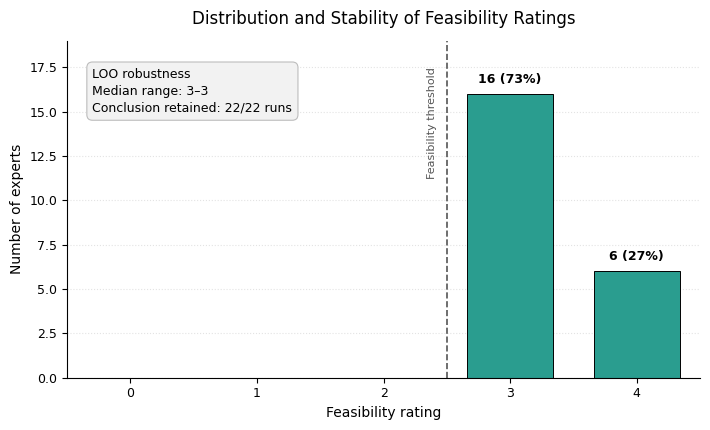

In [28]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

OUTPUT = Path(
    "/Users/HP/Documents/second-publication/current-analysis/"
    "re-run/rq1-rerun/experts-consistency/output"
)

feasibility = pd.read_csv(
    OUTPUT / "loo_feasibility_details.csv"
)

# Each expert appears once as the removed expert, so removed_rating
# reconstructs the original distribution of expert ratings.
rating_scale = np.arange(0, 5)

rating_counts = (
    feasibility["removed_rating"]
    .value_counts()
    .reindex(rating_scale, fill_value=0)
    .sort_index()
)

n_experts = len(feasibility)
rating_percentages = rating_counts / n_experts * 100

full_median = feasibility["loo_median"].median()
minimum_loo_median = feasibility["loo_median"].min()
maximum_loo_median = feasibility["loo_median"].max()

n_conclusions_retained = (
    ~feasibility["conclusion_changed"]
).sum()

# Ratings below 3 are below the feasibility threshold.
bar_colors = [
    "#D9D9D9" if rating < 3 else "#2A9D8F"
    for rating in rating_scale
]

fig, ax = plt.subplots(figsize=(7.2, 4.4))

bars = ax.bar(
    rating_scale,
    rating_counts,
    width=0.68,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.7,
)

# Label only bars with observations.
for bar, count, percentage in zip(
    bars,
    rating_counts,
    rating_percentages,
):
    if count > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.45,
            f"{count} ({percentage:.0f}%)",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )

# The rating-level feasibility threshold lies between 2 and 3.
ax.axvline(
    x=2.5,
    color="#555555",
    linestyle="--",
    linewidth=1.2,
)

ax.text(
    2.42,
    17.5,
    "Feasibility threshold",
    rotation=90,
    ha="right",
    va="top",
    fontsize=8,
    color="#555555",
)

# Compact LOO summary in the otherwise empty part of the plot.
summary_text = (
    f"LOO robustness\n"
    f"Median range: "
    f"{minimum_loo_median:g}–{maximum_loo_median:g}\n"
    f"Conclusion retained: "
    f"{n_conclusions_retained}/{n_experts} runs"
)

ax.text(
    0.04,
    0.92,
    summary_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    linespacing=1.4,
    bbox={
        "boxstyle": "round,pad=0.45",
        "facecolor": "#F2F2F2",
        "edgecolor": "#BDBDBD",
        "linewidth": 0.8,
    },
)

ax.set_title(
    "Distribution and Stability of Feasibility Ratings",
    fontsize=12,
    pad=12,
)

ax.set_xlabel("Feasibility rating", fontsize=10)
ax.set_ylabel("Number of experts", fontsize=10)

ax.set_xticks(rating_scale)
ax.set_xlim(-0.5, 4.5)
ax.set_ylim(0, 19)

ax.tick_params(axis="both", labelsize=9)
ax.grid(axis="y", linestyle=":", alpha=0.35)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

fig.savefig(
    OUTPUT / "feasibility_loo_stability.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    OUTPUT / "feasibility_loo_stability.eps",
    format="eps",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


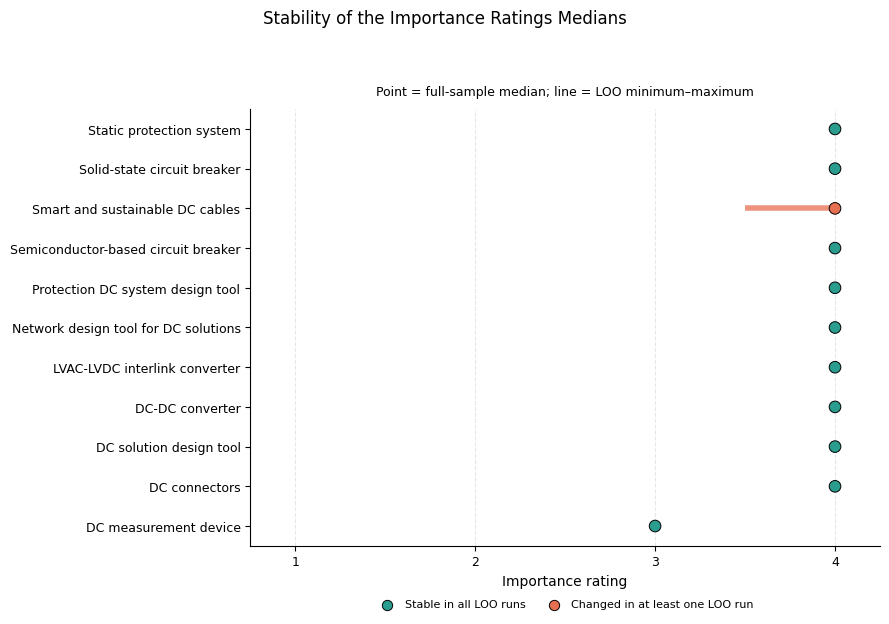

In [29]:
# Importance: horizontal point-range plot

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

OUTPUT = Path(
    "/Users/HP/Documents/second-publication/current-analysis/"
    "re-run/rq1-rerun/experts-consistency/output"
)

# Read summary data
importance = pd.read_csv(
    OUTPUT / "loo_importance_summary.csv"
)

# Sort first by full-sample median and then by technology name.
importance = (
    importance
    .sort_values(
        ["full_median", "technology"],
        ascending=[True, True],
    )
    .reset_index(drop=True)
)

y = np.arange(len(importance))

# Determine whether each technology's median was stable.
stable = importance["median_stable_under_all_removals"]

stable_color = "#2A9D8F"
changed_color = "#E76F51"

colors = np.where(
    stable,
    stable_color,
    changed_color,
)

# Slightly taller figure to accommodate long technology labels.
fig, ax = plt.subplots(figsize=(9, 7))

# Draw the LOO minimum–maximum range.
for position, row in importance.iterrows():
    ax.hlines(
        y=position,
        xmin=row["minimum_loo_median"],
        xmax=row["maximum_loo_median"],
        color=colors[position],
        linewidth=4,
        alpha=0.75,
        zorder=1,
    )

# Draw the full-sample median.
ax.scatter(
    importance["full_median"],
    y,
    c=colors,
    s=70,
    edgecolor="black",
    linewidth=0.7,
    zorder=2,
)

# Technology labels
ax.set_yticks(y)
ax.set_yticklabels(
    importance["technology"],
    fontsize=9,
)

# Importance rating scale
ax.set_xticks(np.arange(1, 5, 1))
ax.set_xlim(0.75, 4.25)
ax.tick_params(axis="x", labelsize=9)

ax.set_xlabel(
    "Importance rating",
    fontsize=10,
)

ax.set_ylabel("")

# Separate the main title and explanatory subtitle.
fig.suptitle(
    "Stability of the Importance Ratings Medians",
    fontsize=12,
    y=0.98,
)

ax.set_title(
    "Point = full-sample median; line = LOO minimum–maximum",
    fontsize=9,
    pad=10,
)

# Legend handles
stable_handle = ax.scatter(
    [],
    [],
    color=stable_color,
    edgecolor="black",
    linewidth=0.7,
    s=55,
    label="Stable in all LOO runs",
)

changed_handle = ax.scatter(
    [],
    [],
    color=changed_color,
    edgecolor="black",
    linewidth=0.7,
    s=55,
    label="Changed in at least one LOO run",
)

# Place the legend below the plotting area.
ax.legend(
    handles=[stable_handle, changed_handle],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=2,
    frameon=False,
    fontsize=8,
    handletextpad=0.6,
    columnspacing=1.5,
)

# Plot styling
ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.8,
    alpha=0.3,
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Reserve space for:
# - the main title at the top;
# - long technology labels on the left;
# - the legend at the bottom.
fig.tight_layout(
    rect=[0.0, 0.08, 1.0, 0.94]
)

# Save PNG
fig.savefig(
    OUTPUT / "importance_loo_point_range.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

# Save EPS
fig.savefig(
    OUTPUT / "importance_loo_point_range.eps",
    format="eps",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


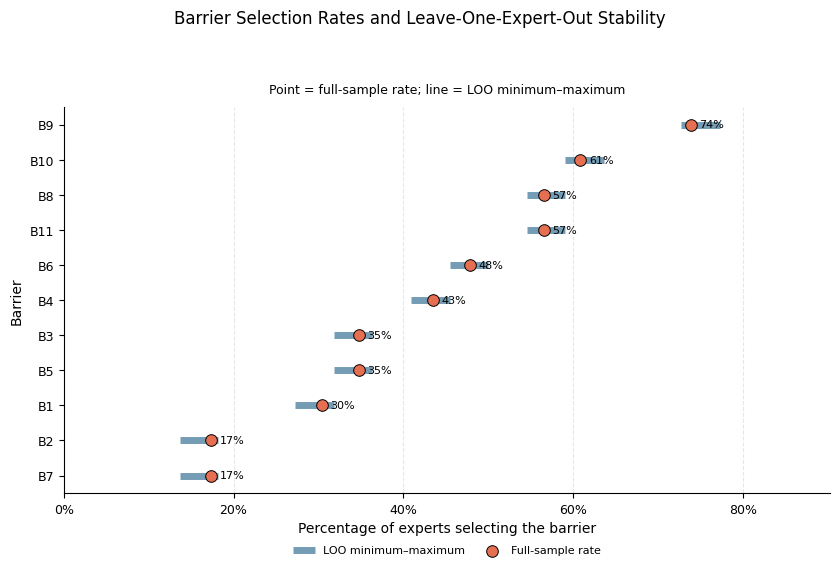

In [30]:
# Barrier: ranked horizontal interval plot

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter

OUTPUT = Path(
    "/Users/HP/Documents/second-publication/current-analysis/"
    "re-run/rq1-rerun/experts-consistency/output"
)

# Read the long-form leave-one-out results.
barrier_rates = pd.read_csv(
    OUTPUT / "loo_barrier_rates.csv"
)

# Summarize the LOO results for each barrier.
barrier_summary = (
    barrier_rates
    .groupby("barrier_id", as_index=False)
    .agg(
        full_sample_rate=("full_sample_rate", "first"),
        minimum_loo_rate=("loo_selection_rate", "min"),
        maximum_loo_rate=("loo_selection_rate", "max"),
    )
)

# Create concise barrier labels.
barrier_summary["barrier_label"] = (
    "B" + barrier_summary["barrier_id"].astype(str)
)

# Rank barriers from highest to lowest full-sample selection rate.
barrier_summary = (
    barrier_summary
    .sort_values(
        "full_sample_rate",
        ascending=False,
    )
    .reset_index(drop=True)
)

y = np.arange(len(barrier_summary))

# Slightly taller figure to accommodate the legend below the chart.
fig, ax = plt.subplots(figsize=(8.5, 6.5))

interval_color = "#457B9D"
point_color = "#E76F51"

# Draw the LOO minimum–maximum intervals.
ax.hlines(
    y=y,
    xmin=barrier_summary["minimum_loo_rate"],
    xmax=barrier_summary["maximum_loo_rate"],
    color=interval_color,
    linewidth=5,
    alpha=0.75,
    label="LOO minimum–maximum",
    zorder=1,
)

# Draw the full-sample selection rates.
ax.scatter(
    barrier_summary["full_sample_rate"],
    y,
    color=point_color,
    edgecolor="black",
    linewidth=0.7,
    s=70,
    label="Full-sample rate",
    zorder=2,
)

# Add full-sample percentages beside the points.
for position, row in barrier_summary.iterrows():
    ax.annotate(
        f'{row["full_sample_rate"]:.0%}',
        xy=(row["full_sample_rate"], position),
        xytext=(6, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=8,
    )

# Barrier labels
ax.set_yticks(y)
ax.set_yticklabels(
    barrier_summary["barrier_label"],
    fontsize=9,
)

# Highest-ranked barrier appears at the top.
ax.invert_yaxis()

# Leave sufficient room on the right for percentage annotations.
largest_displayed_rate = max(
    barrier_summary["maximum_loo_rate"].max(),
    barrier_summary["full_sample_rate"].max(),
)

upper_limit = min(
    1.0,
    largest_displayed_rate + 0.13,
)

ax.set_xlim(0, upper_limit)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.tick_params(axis="x", labelsize=9)

ax.set_xlabel(
    "Percentage of experts selecting the barrier",
    fontsize=10,
)

ax.set_ylabel(
    "Barrier",
    fontsize=10,
)

# Separate main title and explanatory subtitle.
fig.suptitle(
    "Barrier Selection Rates and Leave-One-Expert-Out Stability",
    fontsize=12,
    y=0.98,
)

ax.set_title(
    "Point = full-sample rate; line = LOO minimum–maximum",
    fontsize=9,
    pad=10,
)

# Place the legend below the chart.
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.11),
    ncol=2,
    frameon=False,
    fontsize=8,
    handletextpad=0.7,
    columnspacing=1.5,
)

# Plot styling
ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.8,
    alpha=0.3,
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Reserve space for the title and subtitle at the top
# and the legend at the bottom.
fig.tight_layout(
    rect=[0.0, 0.09, 1.0, 0.94]
)

# Save PNG
fig.savefig(
    OUTPUT / "barrier_loo_interval_plot.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

# Save EPS
fig.savefig(
    OUTPUT / "barrier_loo_interval_plot.eps",
    format="eps",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

In [ ]:
# Barrier: ranked horizontal interval plot

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter

OUTPUT = Path(
    "/Users/HP/Documents/second-publication/current-analysis/"
    "re-run/rq1-rerun/experts-consistency/output"
)

# Read the long-form leave-one-out results.
barrier_rates = pd.read_csv(
    OUTPUT / "loo_barrier_rates.csv"
)

# Summarize the LOO results for each barrier.
barrier_summary = (
    barrier_rates
    .groupby("barrier_id", as_index=False)
    .agg(
        full_sample_rate=("full_sample_rate", "first"),
        minimum_loo_rate=("loo_selection_rate", "min"),
        maximum_loo_rate=("loo_selection_rate", "max"),
    )
)

# Calculate the total change across the LOO range.
barrier_summary["loo_change"] = (
    barrier_summary["maximum_loo_rate"]
    - barrier_summary["minimum_loo_rate"]
)

# Create concise barrier labels.
barrier_summary["barrier_label"] = (
    "B" + barrier_summary["barrier_id"].astype(str)
)

# Rank barriers from highest to lowest full-sample selection rate.
barrier_summary = (
    barrier_summary
    .sort_values(
        "full_sample_rate",
        ascending=False,
    )
    .reset_index(drop=True)
)

y = np.arange(len(barrier_summary))

fig, ax = plt.subplots(figsize=(9.5, 6.5))

interval_color = "#457B9D"
point_color = "#E76F51"

# Draw the LOO minimum–maximum intervals.
ax.hlines(
    y=y,
    xmin=barrier_summary["minimum_loo_rate"],
    xmax=barrier_summary["maximum_loo_rate"],
    color=interval_color,
    linewidth=5,
    alpha=0.75,
    label="LOO minimum–maximum",
    zorder=1,
)

# Draw the full-sample selection rates.
ax.scatter(
    barrier_summary["full_sample_rate"],
    y,
    color=point_color,
    edgecolor="black",
    linewidth=0.7,
    s=70,
    label="Full-sample rate",
    zorder=2,
)

# Annotate the full-sample rate and total LOO change.
for position, row in barrier_summary.iterrows():

    # Full-sample rate above the point.
    ax.annotate(
        f'Full: {row["full_sample_rate"]:.1%}',
        xy=(row["full_sample_rate"], position),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
        color=point_color,
        fontweight="bold",
        annotation_clip=False,
    )

    # Difference between the maximum and minimum LOO rates.
    ax.annotate(
    rf'$\Delta_{{\mathrm{{LOO}}}}$: '
    f'{row["loo_change"] * 100:.1f} pp',
    xy=(row["maximum_loo_rate"], position),
    xytext=(7, -8),
    textcoords="offset points",
    ha="left",
    va="top",
    fontsize=8,
    color=interval_color,
    annotation_clip=False,
)

# Barrier labels.
ax.set_yticks(y)
ax.set_yticklabels(
    barrier_summary["barrier_label"],
    fontsize=9,
)

# Highest-ranked barrier appears at the top.
ax.invert_yaxis()

# Leave room for annotations.
largest_displayed_rate = max(
    barrier_summary["maximum_loo_rate"].max(),
    barrier_summary["full_sample_rate"].max(),
)

upper_limit = min(
    1.0,
    largest_displayed_rate + 0.22,
)

ax.set_xlim(0, upper_limit)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.tick_params(axis="x", labelsize=9)

ax.set_xlabel(
    "Percentage of experts selecting the barrier",
    fontsize=10,
)

ax.set_ylabel(
    "Barrier",
    fontsize=10,
)

fig.suptitle(
    "Barrier Selection Rates and Leave-One-Expert-Out Stability",
    fontsize=12,
    y=0.98,
)

ax.set_title(
    "Point = full-sample rate; line = LOO minimum–maximum",
    fontsize=9,
    pad=10,
)

# Place the legend below the chart.
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.11),
    ncol=2,
    frameon=False,
    fontsize=8,
    handletextpad=0.7,
    columnspacing=1.5,
)

# Plot styling.
ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.8,
    alpha=0.3,
)

ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout(
    rect=[0.0, 0.09, 1.0, 0.94]
)

# Save PNG.
fig.savefig(
    OUTPUT / "barrier_loo_interval_new_plot.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

# Save EPS.
fig.savefig(
    OUTPUT / "barrier_loo_interval_new_plot.eps",
    format="eps",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()